# The Best Neighborhood in Pittsburgh: Safety Part
**Name:** Mingyu Chen  
**Dataset:** Pittsburgh Police Incident Data (WPRDC)

## 1. Introduction
When defining the "best" neighborhood in Pittsburgh, one of the most fundamental requirements for high quality of life is **Safety**. A neighborhood can have the best parks, schools, and restaurants, but if residents do not feel safe, it cannot truly be considered the "best." 

For my sub-metric, I will analyze the **Police Incident Data** from the WPRDC. My hypothesis is straightforward: **The safest neighborhood is the one with the lowest number of reported criminal incidents.** By identifying the neighborhoods with the least crime, I can contribute a strong foundational ranking to my group's overall metric.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

file_path = 'bd41992a-987a-4cca-8798-fbe1cd946b07.csv'
df = pd.read_csv(file_path, low_memory=False)

display(df.head(5))

,_id,Report_Number,ReportedDate,ReportedTime,Hour,DayofWeek,ReportedMonth,NIBRS_Coded_Offense,NIBRS_Offense_Code,NIBRS_Offense_Category,NIBRS_Offense_Type,NIBRS_Crime_Against,NIBRS_Offense_Grouping,Violation,XCOORD,YCOORD,Zone,Tract,Neighborhood,Block_Address
0,1,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13A AGGRAVATED ASSAULT,13A,Assault Offenses,Aggravated Assault,Person,A,18 2718 A1 Strangulation Basic - Applying,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
1,2,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,13C INTIMIDATION,13C,Assault Offenses,Intimidation,Person,A,18 2706 A1 Terroristic Threats-General,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
2,3,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,90Z ALL OTHER OFFENSES,90Z,All other Offenses,All other Offenses,Group B,B,75 3733 A Fleeing or Attempting To Elude Polic...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
3,4,PGHP24000024,2024-01-01,00:31,0,Monday,Jan,23H ALL OTHER LARCENY,23H,Larceny/Theft Offenses,All Other Larceny,Property,A,18 3921 A Theft by Unlawful Taking-Movable – L...,-80.0268,40.3964,Zone 6,1919,Brookline,"2800 Block of FITZHUGH WAY Pittsburgh, PA"
4,5,PGHP24000017,2024-01-01,00:21,0,Monday,Jan,9999 Vehicle Offense (Not NIBRS Reportable),999,Not NIBRS Reportable,Not NIBRS Reportable,Group B,B,LO 6 101 Discharge of Firearms Prohibited,-80.0243,40.4582,Zone 1,2107,Manchester,"1200 Block of COLUMBUS AVE Pittsburgh, PA"


## 2. Data Cleaning
Before analyzing the data, I need to clean it to ensure accuracy. Upon initial inspection, I noticed two things that need to be addressed:
1. **Standardizing Neighborhood Names:** "St. Clair" and "Saint Clair" are the same neighborhood but spelled differently in the dataset. I need to merge them.
2. **Filtering Non-Criminal Events:** The police dataset includes many incidents labeled as `Not NIBRS Reportable`. These are often minor, non-criminal miscellany (like lost property or wellness checks). I will filter these out so we are only looking at actual criminal offenses.
3. **Handling Null Values:** I will drop rows where the neighborhood is not recorded.

In [2]:
print(f"Unique neighborhoods before cleaning: {df['Neighborhood'].nunique()}")

#1. Standardizing Neighborhood Names
neighborhood_mapping = {
    'St. Clair': 'Saint Clair',
    'Mt. Oliver Boro': 'Mt. Oliver',
    'Mount Oliver': 'Mt. Oliver',
    'Mt. Washington': 'Mount Washington',
    'Central Northside': 'Central North Side'
}
df['Neighborhood'] = df['Neighborhood'].replace(neighborhood_mapping)
#2. Filtering Non-Criminal Events
df_filtered = df[df['NIBRS_Offense_Category'] != 'Not NIBRS Reportable']
#3. Handling Null Values
df_filtered = df_filtered.dropna(subset=['Neighborhood'])

print(f"Unique neighborhoods after cleaning: {df_filtered['Neighborhood'].nunique()}")
print(f"Original dataset rows: {len(df)}")
print(f"Cleaned dataset rows: {len(df_filtered)}")

Unique neighborhoods before cleaning: 93
Unique neighborhoods after cleaning: 92
Original dataset rows: 85451
Cleaned dataset rows: 62557


## 3. Data Analysis: Counting Incidents
Now that the data is clean and focuses on true offenses, I will calculate the total number of incidents for each neighborhood. To find the "best" (safest) neighborhood, I am looking for the lowest counts.

In [3]:
crime_counts = df_filtered['Neighborhood'].value_counts()

print("Top 5 Neighborhoods with the HIGHEST crime:")
print(crime_counts.head(5))
print("\n" + "="*50 + "\n")

safest_neighborhoods = crime_counts.tail(15).sort_values(ascending=True)
print("Top 15 Neighborhoods with the LOWEST crime:")
print(safest_neighborhoods)

Top 5 Neighborhoods with the HIGHEST crime:
Neighborhood
Central Business District    7444
South Side Flats             4198
Carrick                      2280
Shadyside                    2020
East Liberty                 1969
Name: count, dtype: int64


Top 15 Neighborhoods with the LOWEST crime:
Neighborhood
Saint Clair               20
Ridgemont                 29
Spring Hill-City View     44
Chartiers                 44
New Homestead             50
Swisshelm Park            63
East Carnegie             69
Summer Hill               75
Hays                      78
Regent Square             79
Esplen                    79
Oakwood                   97
Fairywood                 99
Allegheny West           114
Mt. Oliver               128
Name: count, dtype: int64


## 4. Data Visualization
To make this data-driven argument clearer, I will visualize the Top 15 safest neighborhoods using a horizontal bar chart. This allows us to easily compare the crime levels among the best-performing areas.

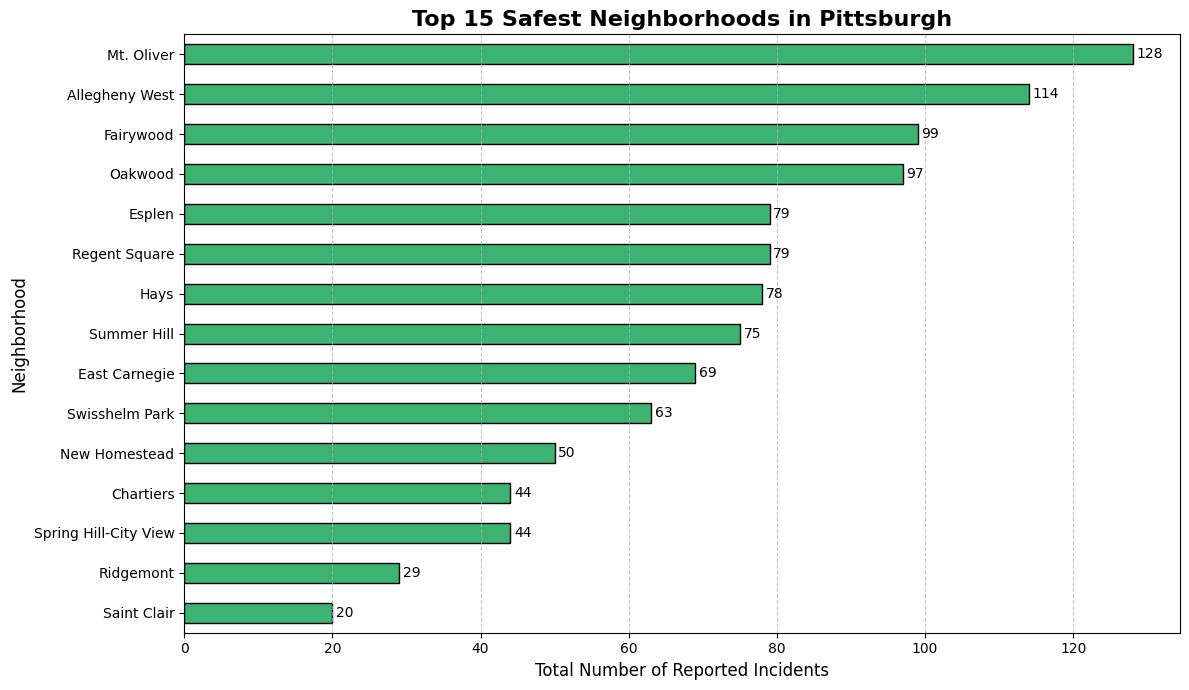

In [4]:
plt.figure(figsize=(12, 7))

safest_neighborhoods.sort_values(ascending=True).plot(
    kind='barh', 
    color='mediumseagreen', 
    edgecolor='black'
)
plt.title('Top 15 Safest Neighborhoods in Pittsburgh', fontsize=16, fontweight='bold')
plt.xlabel('Total Number of Reported Incidents', fontsize=12)
plt.ylabel('Neighborhood', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(safest_neighborhoods.sort_values(ascending=True)):
    plt.text(value + 0.5, index, str(value), va='center', fontsize=10)

plt.tight_layout()
plt.show()

## 5. Conclusion
Based strictly on the data analysis of police incidents, the safest neighborhood in Pittsburgh is **Saint Clair** (with only 20 valid reported incidents in the dataset), followed closely by **Ridgemont**, **Spring Hill-City View** and **Chartiers**. 

**Safety Part Winner:** Saint Clair

**Reflection:**
While Saint Clair wins the safety part, defining the absolute "best" neighborhood requires a more holistic view. Saint Clair is very safe, but it is also a very small, somewhat isolated residential area with fewer commercial amenities. If someone values peace, quiet, and low crime above all else, the data strongly supports Saint Clair as the best choice. However, if they value walkability or nightlife, they might prefer a neighborhood with slightly more crime but more activities, such as Squirrel Hill. 